# Exploratory Data Analysis — Sensor Selection for RUL Prediction

**Project:** Bayesian Digital Twins for Predictive Maintenance  
**Input:** 14 informative sensors identified in IDA (7 constant sensors already excluded)  
**Goal:** Rank and select sensors that carry reliable degradation signal for RUL prediction.

## Selection criteria (applied in this order)

| Method | Purpose |
|---|---|
| Mann-Kendall test | Detect statistically significant monotonic trend |
| Monotonicity score | Quantify directional consistency of degradation signal |
| Trendability score | Measure signal consistency **across** engines |
| Mutual Information (MI) | Assess nonlinear relevance to RUL |
| VIF | Flag multicollinear sensors for pruning |

## Contents

1. Setup & Data Loading  
2. Operating-Condition Normalisation  
3. Correlation with RUL (baseline)  
4. Mann-Kendall Trend Test  
5. Monotonicity Score  
6. Trendability Score  
7. Mutual Information with RUL  
8. Collinearity — Correlation Matrix & VIF  
9. Composite Sensor Ranking  
10. Final Sensor Selection & Visualisation  
11. Summary & Conclusions

---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pymannkendall as mk
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR  = Path('../data')
FIG_DIR   = Path('../output/figures/EDA')
TABLE_DIR = Path('../output/tables/EDA')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
})
PALETTE = sns.color_palette('tab10')

DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']
INDEX_COLS   = ['unit_id', 'cycle']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_NAMES = [
    'T2','T24','T30','T50','P2','P15','P30','Nf','Nc','epr',
    'Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32'
]
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_NAMES

# Sensors with zero variance (identified in IDA) — excluded throughout EDA
CONSTANT_SENSORS = ['T2', 'P2', 'P15', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
INFORMATIVE = [s for s in SENSOR_NAMES if s not in CONSTANT_SENSORS]  # 14 sensors
print(f'Informative sensors ({len(INFORMATIVE)}): {INFORMATIVE}')

Informative sensors (14): ['T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']


In [2]:
def load_dataset(name):
    train = pd.read_csv(DATA_DIR / f'train_{name}.txt', sep=r'\s+', header=None, names=ALL_COLS)
    test  = pd.read_csv(DATA_DIR / f'test_{name}.txt',  sep=r'\s+', header=None, names=ALL_COLS)
    rul   = pd.read_csv(DATA_DIR / f'RUL_{name}.txt',   sep=r'\s+', header=None, names=['true_rul'])['true_rul']
    max_cyc = train.groupby('unit_id')['cycle'].transform('max')
    train['RUL'] = max_cyc - train['cycle']
    return train, test, rul

data = {}
for ds in DATASETS:
    tr, te, ru = load_dataset(ds)
    data[ds] = {'train': tr, 'test': te, 'rul': ru}

# Primary working dataset: FD001 (single op. condition, simplest case)
df = data['FD001']['train'].copy()
print('FD001 train shape:', df.shape)

FD001 train shape: (20631, 27)


---
## 2. Operating-Condition Normalisation

FD001/FD003 have a single flight regime — raw sensor values are directly comparable.  
FD002/FD004 have 6 regimes; sensors must be normalised within each operating cluster before degradation analysis.

We assign clusters via rounded `(setting_1, setting_2)` and z-score normalise within each cluster.

In [3]:
def assign_op_cluster(df):
    """Assign integer cluster label based on rounded operational settings."""
    key = df['setting_1'].round(0).astype(int).astype(str) + '_' + df['setting_2'].round(2).astype(str)
    cluster_map = {v: i for i, v in enumerate(sorted(key.unique()))}
    return key.map(cluster_map)


def normalise_by_cluster(df, sensors):
    """Z-score each sensor within its operating cluster."""
    df = df.copy()
    df['op_cluster'] = assign_op_cluster(df)
    for s in sensors:
        df[s + '_norm'] = df.groupby('op_cluster')[s].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9)
        )
    return df


# Normalise all datasets
data_norm = {}
for ds in DATASETS:
    data_norm[ds] = normalise_by_cluster(data[ds]['train'], INFORMATIVE)
    n_clusters = data_norm[ds]['op_cluster'].nunique()
    print(f'{ds}: {n_clusters} operating cluster(s)')

NORM_SENSORS = [s + '_norm' for s in INFORMATIVE]

FD001: 2 operating cluster(s)
FD002: 6 operating cluster(s)
FD003: 2 operating cluster(s)


FD004: 6 operating cluster(s)


---
## 3. Correlation with RUL (Baseline)

Pearson and Spearman correlation with RUL give a quick baseline.  
These are linear and rank-based respectively and cannot capture all degradation patterns, but useful for orientation.

In [4]:
corr_rows = []
for ds in DATASETS:
    df_n = data_norm[ds]
    for s in INFORMATIVE:
        col = s + '_norm'
        pearson_r, pearson_p = stats.pearsonr(df_n[col], df_n['RUL'])
        spear_r,  spear_p   = stats.spearmanr(df_n[col], df_n['RUL'])
        corr_rows.append({
            'Dataset': ds, 'Sensor': s,
            'Pearson_r': round(pearson_r, 4), 'Pearson_p': round(pearson_p, 6),
            'Spearman_r': round(spear_r, 4),  'Spearman_p': round(spear_p, 6),
        })

corr_df = pd.DataFrame(corr_rows)

# Pivot for display: FD001 Pearson
fd001_corr = corr_df[corr_df['Dataset'] == 'FD001'][['Sensor', 'Pearson_r', 'Spearman_r']].set_index('Sensor').sort_values('Pearson_r')
display(fd001_corr)
corr_df.to_csv(TABLE_DIR / 'rul_correlations.csv', index=False)
print('Saved → output/tables/EDA/rul_correlations.csv')

,Pearson_r,Spearman_r
Sensor,,
Ps30,-0.6962,-0.7181
T50,-0.6789,-0.7017
BPR,-0.6426,-0.6658
T24,-0.6064,-0.6286
htBleed,-0.6061,-0.6199
T30,-0.5845,-0.6055
Nf,-0.5640,-0.5734
NRf,-0.5625,-0.5722
Nc,-0.3902,-0.3221


Saved → output/tables/EDA/rul_correlations.csv


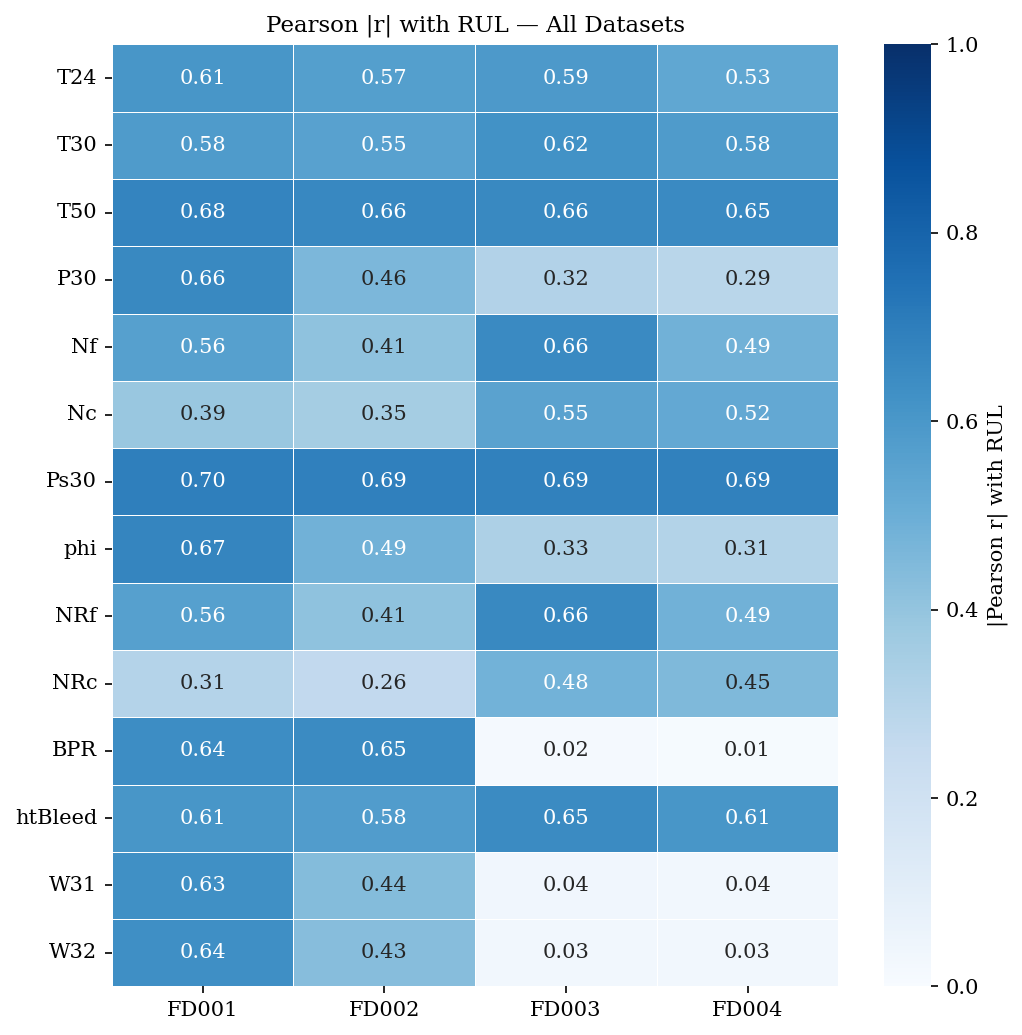

Saved → output/figures/EDA/pearson_rul_heatmap.png


In [5]:
# Heatmap of Pearson |r| with RUL across all datasets
pearson_pivot = corr_df.pivot_table(index='Sensor', columns='Dataset', values='Pearson_r', aggfunc='first')
pearson_abs   = pearson_pivot.abs().loc[INFORMATIVE]

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(
    pearson_abs, annot=True, fmt='.2f',
    cmap='Blues', vmin=0, vmax=1, linewidths=0.4, ax=ax,
    cbar_kws={'label': '|Pearson r| with RUL'}
)
ax.set_title('Pearson |r| with RUL — All Datasets', fontsize=11)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
fig.savefig(FIG_DIR / 'pearson_rul_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/EDA/pearson_rul_heatmap.png')

---
## 4. Mann-Kendall Trend Test

The **Mann-Kendall test** (Kendall 1975) is a nonparametric test for monotonic trend.  
We apply it **per engine** and report:
- `tau`: mean Kendall τ across engines (sign indicates direction; magnitude indicates consistency)
- `sig_frac`: fraction of engines where trend is significant at α = 0.05

Sensors with large `|tau|` and high `sig_frac` are reliable trend carriers.

In [6]:
def mann_kendall_sensor(df, sensor_col, alpha=0.05):
    """Run Mann-Kendall per engine; return mean tau and fraction significant."""
    taus, sigs = [], []
    for uid, grp in df.groupby('unit_id'):
        series = grp.sort_values('cycle')[sensor_col].values
        if len(series) < 4:
            continue
        result = mk.original_test(series, alpha=alpha)
        taus.append(result.Tau)
        sigs.append(1 if result.p < alpha else 0)
    return np.mean(taus), np.mean(sigs)


mk_rows = []
for ds in DATASETS:
    df_n = data_norm[ds]
    for s in INFORMATIVE:
        tau_mean, sig_frac = mann_kendall_sensor(df_n, s + '_norm')
        mk_rows.append({
            'Dataset': ds, 'Sensor': s,
            'MK_tau': round(tau_mean, 4),
            'MK_sig_frac': round(sig_frac, 4),
        })

mk_df = pd.DataFrame(mk_rows)

# FD001 summary
fd001_mk = mk_df[mk_df['Dataset'] == 'FD001'].set_index('Sensor').sort_values('MK_sig_frac', ascending=False)
display(fd001_mk)
mk_df.to_csv(TABLE_DIR / 'mann_kendall.csv', index=False)
print('Saved → output/tables/EDA/mann_kendall.csv')

,Dataset,MK_tau,MK_sig_frac
Sensor,,,
T24,FD001,0.4811,1.00
T30,FD001,0.4525,1.00
T50,FD001,0.5887,1.00
P30,FD001,-0.5683,1.00
Ps30,FD001,0.6291,1.00
phi,FD001,-0.6017,1.00
BPR,FD001,0.5269,1.00
htBleed,FD001,0.4651,1.00
W31,FD001,-0.5179,1.00


Saved → output/tables/EDA/mann_kendall.csv


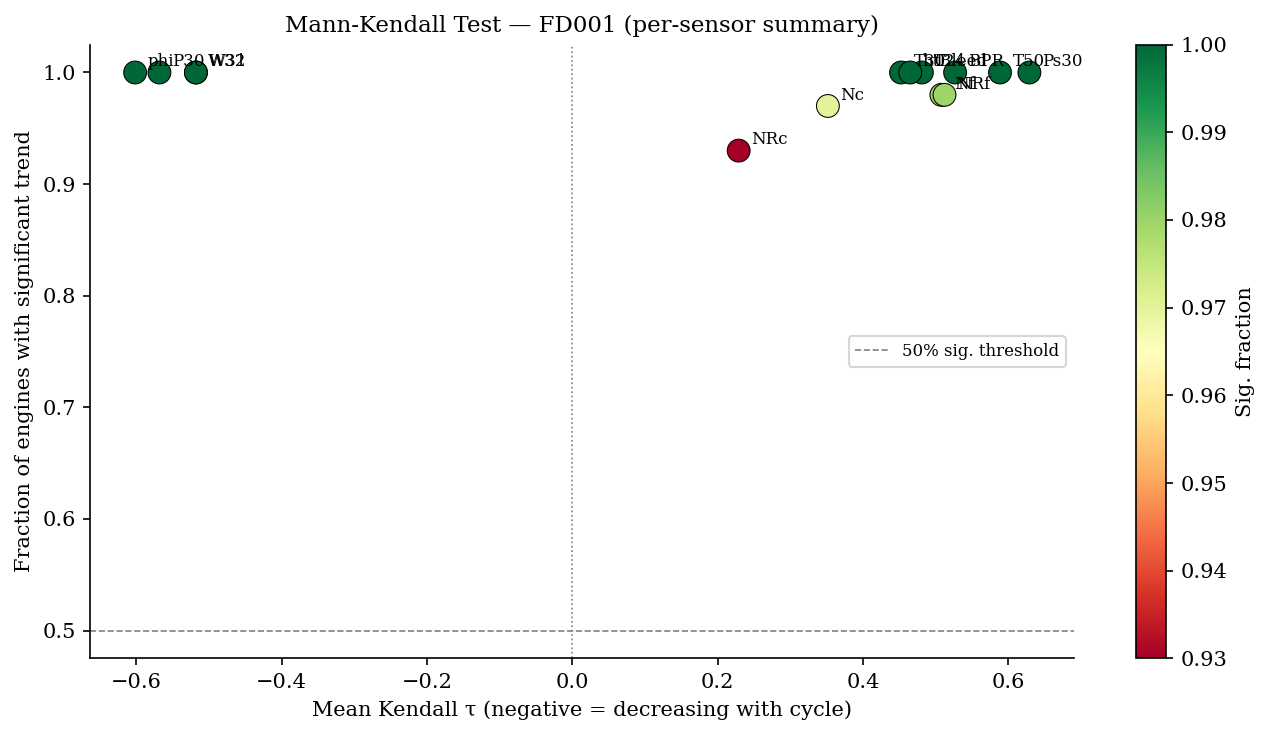

Saved → output/figures/EDA/mann_kendall_FD001.png


In [7]:
# Bubble chart: MK tau vs significance fraction (FD001)
fd001_mk_r = fd001_mk.reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    fd001_mk_r['MK_tau'], fd001_mk_r['MK_sig_frac'],
    c=fd001_mk_r['MK_sig_frac'], cmap='RdYlGn', s=120, edgecolors='k', linewidths=0.5
)
for _, row in fd001_mk_r.iterrows():
    ax.annotate(row['Sensor'], (row['MK_tau'], row['MK_sig_frac']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='50% sig. threshold')
ax.axvline(0.0, color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel('Mean Kendall τ (negative = decreasing with cycle)')
ax.set_ylabel('Fraction of engines with significant trend')
ax.set_title('Mann-Kendall Test — FD001 (per-sensor summary)', fontsize=11)
plt.colorbar(sc, ax=ax, label='Sig. fraction')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / 'mann_kendall_FD001.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/EDA/mann_kendall_FD001.png')

---
## 5. Monotonicity Score

**Monotonicity** measures the directional consistency of a sensor's degradation signal within each engine.  
For a sequence $x_1, \ldots, x_n$:

$$
\text{Mon}(x) = \left| \frac{\#\{i: x_{i+1} > x_i\} - \#\{i: x_{i+1} < x_i\}}{n-1} \right|
$$

Score ∈ [0, 1].  Score = 1 means perfectly monotone; 0 means symmetric noise.

In [8]:
def monotonicity_score(series: np.ndarray) -> float:
    d = np.diff(series)
    n = len(d)
    if n == 0:
        return np.nan
    return abs((d > 0).sum() - (d < 0).sum()) / n


def sensor_monotonicity(df, sensor_col):
    scores = []
    for uid, grp in df.groupby('unit_id'):
        series = grp.sort_values('cycle')[sensor_col].values
        if len(series) > 1:
            scores.append(monotonicity_score(series))
    return np.mean(scores)


mono_rows = []
for ds in DATASETS:
    df_n = data_norm[ds]
    for s in INFORMATIVE:
        score = sensor_monotonicity(df_n, s + '_norm')
        mono_rows.append({'Dataset': ds, 'Sensor': s, 'Monotonicity': round(score, 4)})

mono_df = pd.DataFrame(mono_rows)

fd001_mono = mono_df[mono_df['Dataset'] == 'FD001'].set_index('Sensor').sort_values('Monotonicity', ascending=False)
display(fd001_mono)
mono_df.to_csv(TABLE_DIR / 'monotonicity_scores.csv', index=False)
print('Saved → output/tables/EDA/monotonicity_scores.csv')

,Dataset,Monotonicity
Sensor,,
NRc,FD001,0.0549
Nc,FD001,0.0446
P30,FD001,0.0444
Ps30,FD001,0.0390
phi,FD001,0.0376
BPR,FD001,0.0371
T50,FD001,0.0364
W32,FD001,0.0364
T24,FD001,0.0355


Saved → output/tables/EDA/monotonicity_scores.csv


---
## 6. Trendability Score

**Trendability** measures whether the degradation pattern is consistent **across engines** — i.e. engines degrade in the same direction.  
We define it as the mean absolute Pearson correlation between the sensor signal and normalised cycle position $t/T_i \in [0,1]$, averaged across engines:

$$
\text{Trend}(s) = \frac{1}{N}\sum_{i=1}^{N} \left|\text{corr}\left(s_i(t),\; t/T_i\right)\right|
$$

Score ∈ [0, 1]. Score = 1 means every engine shows the same linear trend.

In [9]:
def sensor_trendability(df, sensor_col):
    corrs = []
    for uid, grp in df.groupby('unit_id'):
        grp = grp.sort_values('cycle')
        n = len(grp)
        if n < 4:
            continue
        t_norm = np.linspace(0, 1, n)  # normalised cycle position
        r, _ = stats.pearsonr(grp[sensor_col].values, t_norm)
        if not np.isnan(r):
            corrs.append(abs(r))
    return np.mean(corrs) if corrs else np.nan


trend_rows = []
for ds in DATASETS:
    df_n = data_norm[ds]
    for s in INFORMATIVE:
        score = sensor_trendability(df_n, s + '_norm')
        trend_rows.append({'Dataset': ds, 'Sensor': s, 'Trendability': round(score, 4)})

trend_df = pd.DataFrame(trend_rows)

fd001_trend = trend_df[trend_df['Dataset'] == 'FD001'].set_index('Sensor').sort_values('Trendability', ascending=False)
display(fd001_trend)
trend_df.to_csv(TABLE_DIR / 'trendability_scores.csv', index=False)
print('Saved → output/tables/EDA/trendability_scores.csv')

,Dataset,Trendability
Sensor,,
Ps30,FD001,0.8105
phi,FD001,0.7896
T50,FD001,0.7815
P30,FD001,0.7614
BPR,FD001,0.7247
W32,FD001,0.7167
W31,FD001,0.7141
NRf,FD001,0.6872
Nf,FD001,0.6834


Saved → output/tables/EDA/trendability_scores.csv


---
## 7. Mutual Information with RUL

**Mutual Information** captures nonlinear statistical dependence between a sensor and RUL — unlike Pearson correlation it detects any functional relationship.  
We use `sklearn.feature_selection.mutual_info_regression` with 5 nearest neighbours.

In [10]:
mi_rows = []
for ds in DATASETS:
    df_n = data_norm[ds].dropna(subset=NORM_SENSORS + ['RUL'])
    X = df_n[NORM_SENSORS].values
    y = df_n['RUL'].values
    mi_vals = mutual_info_regression(X, y, n_neighbors=5, random_state=42)
    for s, mi in zip(INFORMATIVE, mi_vals):
        mi_rows.append({'Dataset': ds, 'Sensor': s, 'MI': round(mi, 4)})

mi_df = pd.DataFrame(mi_rows)

fd001_mi = mi_df[mi_df['Dataset'] == 'FD001'].set_index('Sensor').sort_values('MI', ascending=False)
display(fd001_mi)
mi_df.to_csv(TABLE_DIR / 'mutual_information.csv', index=False)
print('Saved → output/tables/EDA/mutual_information.csv')

,Dataset,MI
Sensor,,
Ps30,FD001,0.5016
T50,FD001,0.4632
phi,FD001,0.4433
P30,FD001,0.4222
BPR,FD001,0.3943
W32,FD001,0.3834
W31,FD001,0.3672
T24,FD001,0.3423
htBleed,FD001,0.3344


Saved → output/tables/EDA/mutual_information.csv


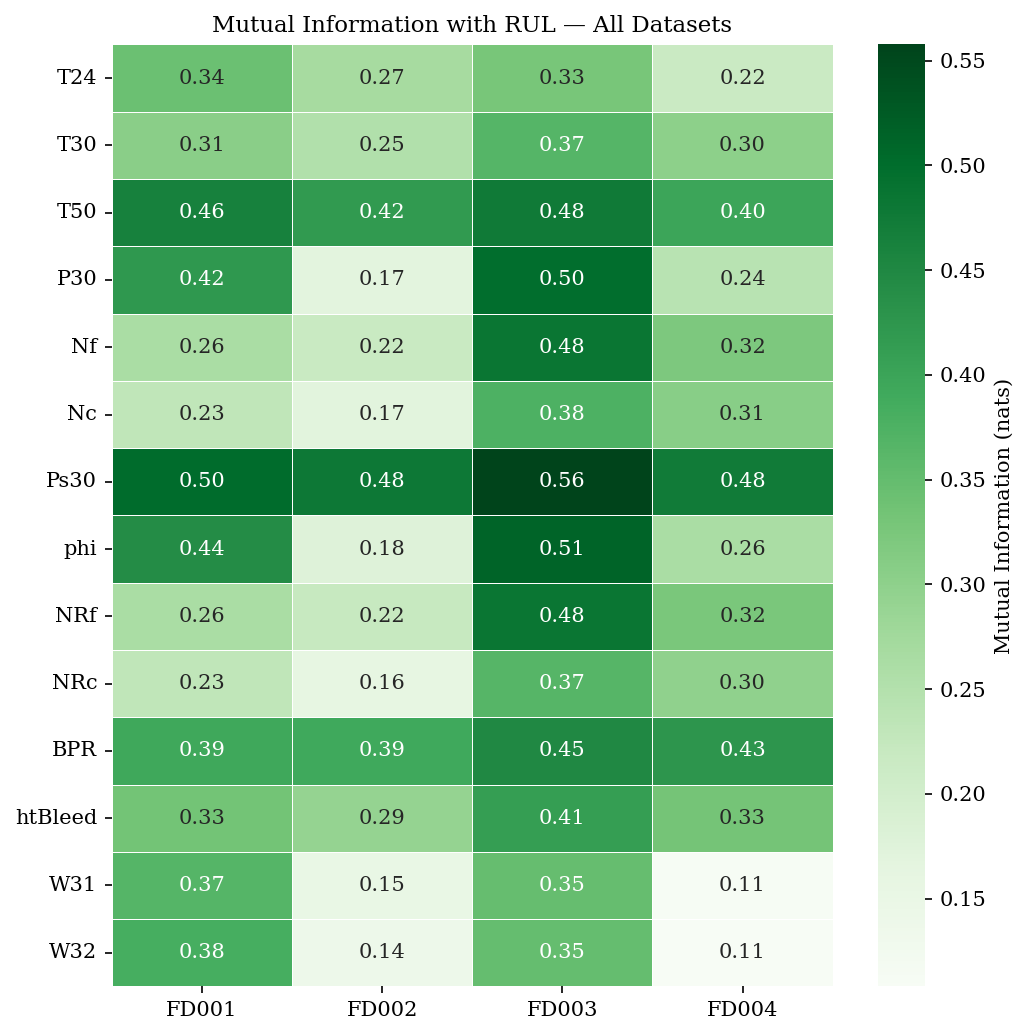

Saved → output/figures/EDA/mutual_information_heatmap.png


In [11]:
# MI heatmap across datasets
mi_pivot = mi_df.pivot_table(index='Sensor', columns='Dataset', values='MI', aggfunc='first').loc[INFORMATIVE]

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(
    mi_pivot, annot=True, fmt='.2f',
    cmap='Greens', linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Mutual Information (nats)'}
)
ax.set_title('Mutual Information with RUL — All Datasets', fontsize=11)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
fig.savefig(FIG_DIR / 'mutual_information_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/EDA/mutual_information_heatmap.png')

---
## 8. Collinearity — Correlation Matrix & VIF

**VIF** (Variance Inflation Factor) quantifies multicollinearity: how much the variance of a sensor's regression coefficient is inflated by correlation with other sensors.  
Rule of thumb: VIF > 10 → severe collinearity; VIF > 5 → moderate concern.  
Removing collinear sensors reduces model complexity without losing predictive information.

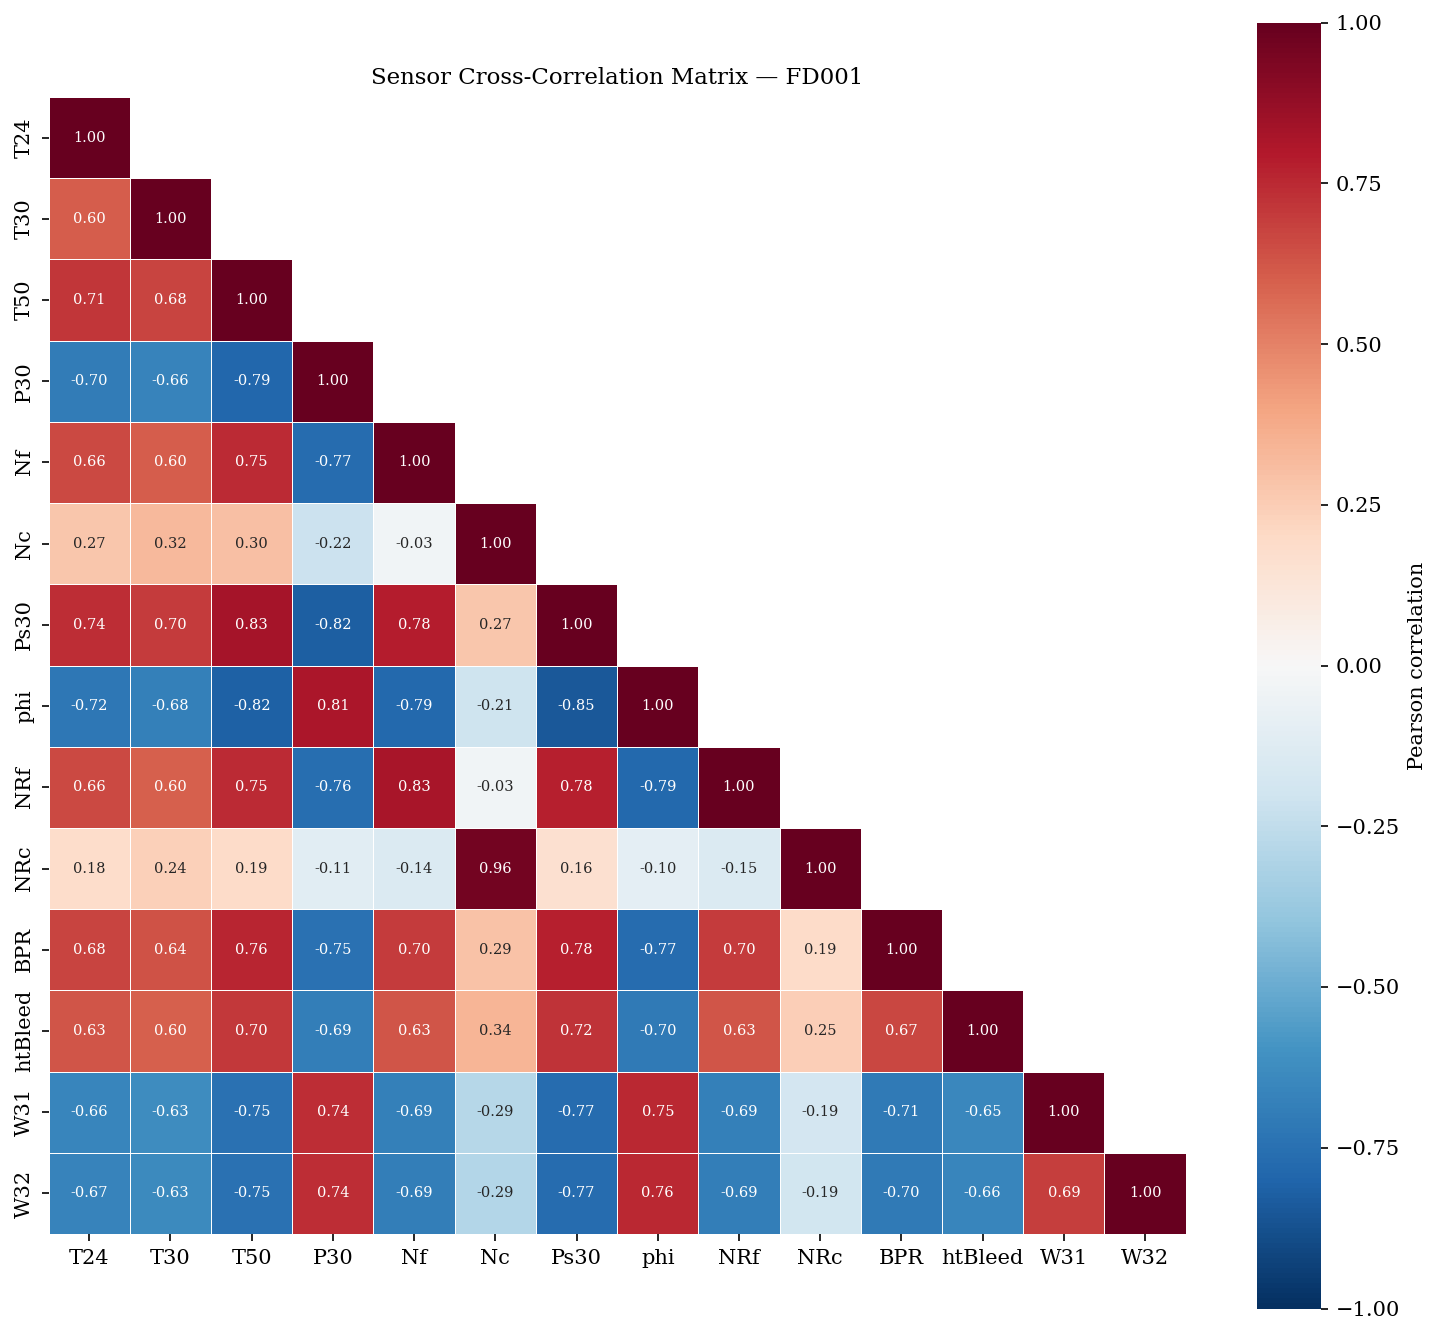

Saved → output/figures/EDA/sensor_correlation_matrix.png


In [12]:
# Correlation matrix — FD001
df_n_fd001 = data_norm['FD001']
corr_matrix = df_n_fd001[NORM_SENSORS].rename(columns=lambda c: c.replace('_norm', '')).corr()

fig, ax = plt.subplots(figsize=(10, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, square=True, ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Pearson correlation'}
)
ax.set_title('Sensor Cross-Correlation Matrix — FD001', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sensor_correlation_matrix.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/EDA/sensor_correlation_matrix.png')

In [13]:
def compute_vif(df, sensor_cols):
    """Compute VIF for each sensor in sensor_cols using a sampled subset for speed."""
    X = df[sensor_cols].dropna()
    # Sample for speed if large
    if len(X) > 10_000:
        X = X.sample(10_000, random_state=42)
    X = X.values
    vif_vals = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return pd.Series(vif_vals, index=[c.replace('_norm', '') for c in sensor_cols])


vif_rows = []
for ds in DATASETS:
    df_n = data_norm[ds]
    vif = compute_vif(df_n, NORM_SENSORS)
    for s, v in vif.items():
        vif_rows.append({'Dataset': ds, 'Sensor': s, 'VIF': round(v, 2)})

vif_df = pd.DataFrame(vif_rows)

fd001_vif = vif_df[vif_df['Dataset'] == 'FD001'].set_index('Sensor').sort_values('VIF', ascending=False)
display(fd001_vif)
vif_df.to_csv(TABLE_DIR / 'vif_scores.csv', index=False)
print('Saved → output/tables/EDA/vif_scores.csv')

,Dataset,VIF
Sensor,,
Nc,FD001,16.94
NRc,FD001,16.38
Ps30,FD001,5.93
phi,FD001,5.19
NRf,FD001,4.71
Nf,FD001,4.62
T50,FD001,4.47
P30,FD001,4.26
BPR,FD001,3.31


Saved → output/tables/EDA/vif_scores.csv


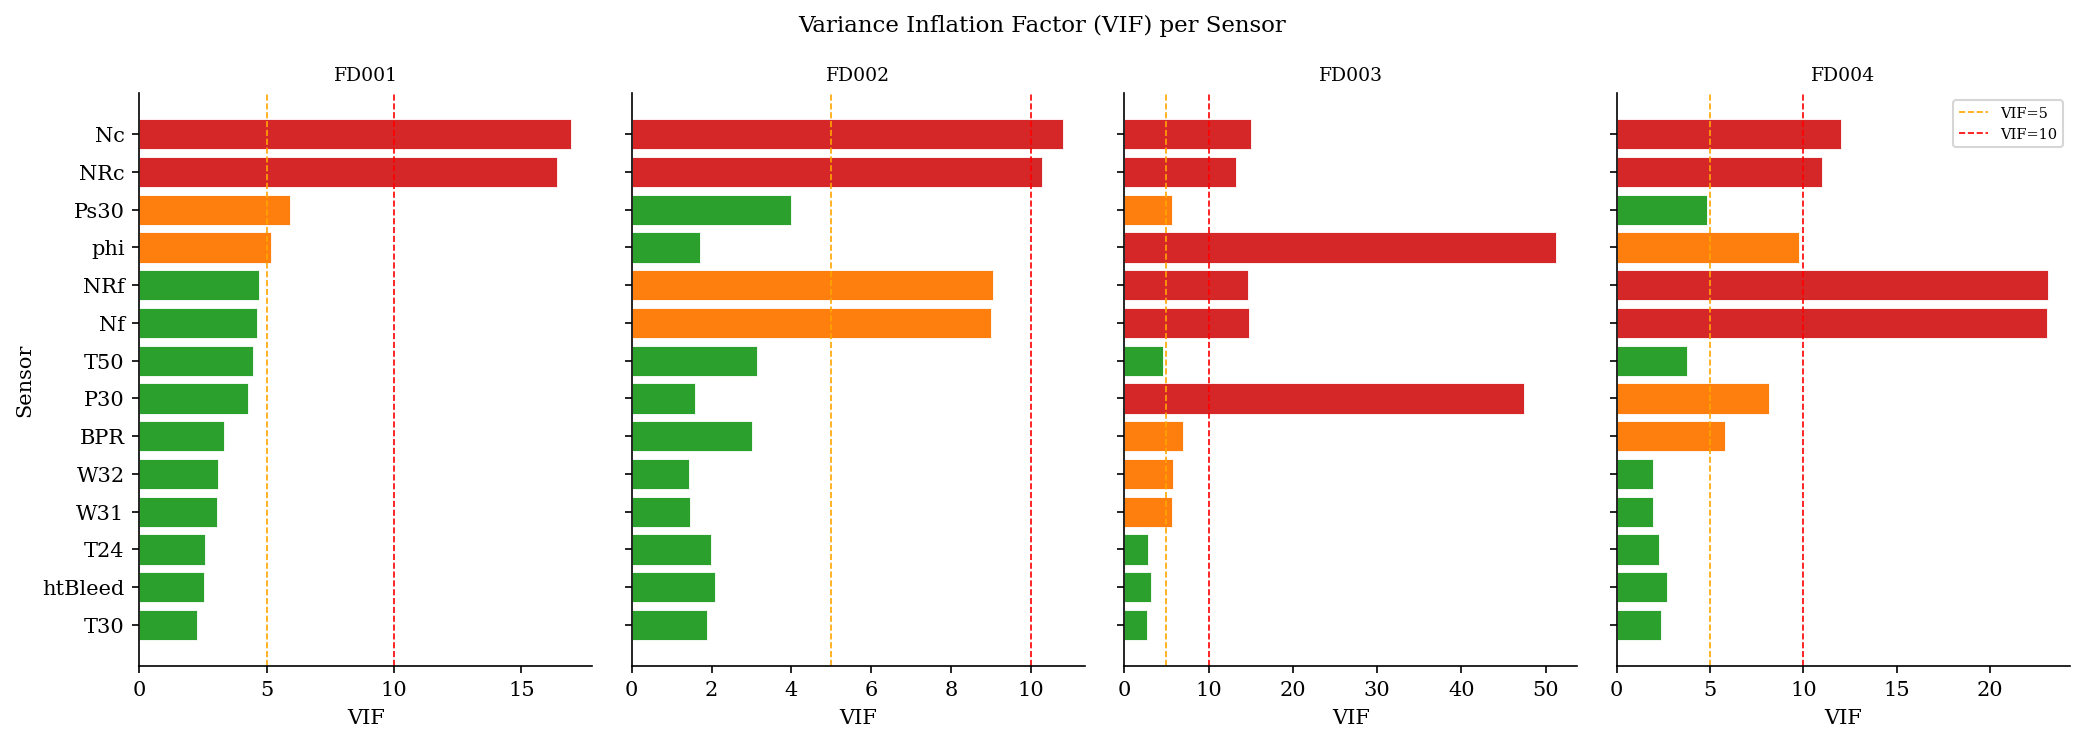

Saved → output/figures/EDA/vif_barchart.png


In [14]:
# VIF bar chart across datasets
vif_pivot = vif_df.pivot_table(index='Sensor', columns='Dataset', values='VIF', aggfunc='first').loc[INFORMATIVE]

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)
fig.suptitle('Variance Inflation Factor (VIF) per Sensor', fontsize=11)

for i, ds in enumerate(DATASETS):
    ax = axes[i]
    vals = vif_pivot[ds].sort_values(ascending=True)
    colors = ['#d62728' if v > 10 else '#ff7f0e' if v > 5 else '#2ca02c' for v in vals]
    ax.barh(vals.index, vals.values, color=colors, edgecolor='white', linewidth=0.4)
    ax.axvline(5,  color='orange', linestyle='--', linewidth=0.8, label='VIF=5')
    ax.axvline(10, color='red',    linestyle='--', linewidth=0.8, label='VIF=10')
    ax.set_title(ds, fontsize=9)
    ax.set_xlabel('VIF')
    if i == 0:
        ax.set_ylabel('Sensor')
    if i == 3:
        ax.legend(fontsize=7)

plt.tight_layout()
fig.savefig(FIG_DIR / 'vif_barchart.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/EDA/vif_barchart.png')

---
## 9. Composite Sensor Ranking

We combine all five criteria into a single composite score by:
1. Normalising each criterion to [0, 1] (min-max)
2. Computing an equally-weighted mean

For VIF, the score is **inverted** (lower VIF = better).  
For `MK_sig_frac`, Monotonicity, Trendability, and MI — higher is better.

In [15]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)


composite_rows = []
for ds in DATASETS:
    # Gather all criteria for this dataset
    base = pd.DataFrame({'Sensor': INFORMATIVE})

    mk_sub    = mk_df[mk_df['Dataset'] == ds][['Sensor', 'MK_sig_frac']].set_index('Sensor')
    mono_sub  = mono_df[mono_df['Dataset'] == ds][['Sensor', 'Monotonicity']].set_index('Sensor')
    trend_sub = trend_df[trend_df['Dataset'] == ds][['Sensor', 'Trendability']].set_index('Sensor')
    mi_sub    = mi_df[mi_df['Dataset'] == ds][['Sensor', 'MI']].set_index('Sensor')
    vif_sub   = vif_df[vif_df['Dataset'] == ds][['Sensor', 'VIF']].set_index('Sensor')

    comp = base.set_index('Sensor').join(mk_sub).join(mono_sub).join(trend_sub).join(mi_sub).join(vif_sub)

    comp['MK_norm']   = minmax(comp['MK_sig_frac'])
    comp['Mono_norm'] = minmax(comp['Monotonicity'])
    comp['Trend_norm']= minmax(comp['Trendability'])
    comp['MI_norm']   = minmax(comp['MI'])
    comp['VIF_norm']  = 1 - minmax(comp['VIF'])  # inverted: low VIF is good

    comp['Composite'] = comp[['MK_norm', 'Mono_norm', 'Trend_norm', 'MI_norm', 'VIF_norm']].mean(axis=1)
    comp['Dataset'] = ds
    composite_rows.append(comp.reset_index())

composite_df = pd.concat(composite_rows, ignore_index=True)

fd001_comp = (
    composite_df[composite_df['Dataset'] == 'FD001']
    [['Sensor', 'MK_sig_frac', 'Monotonicity', 'Trendability', 'MI', 'VIF', 'Composite']]
    .set_index('Sensor').sort_values('Composite', ascending=False).round(4)
)
display(fd001_comp)
composite_df.to_csv(TABLE_DIR / 'composite_sensor_ranking.csv', index=False)
print('Saved → output/tables/EDA/composite_sensor_ranking.csv')

,MK_sig_frac,Monotonicity,Trendability,MI,VIF,Composite
Sensor,,,,,,
Ps30,1.00,0.0390,0.8105,0.5016,5.93,0.8136
P30,1.00,0.0444,0.7614,0.4222,4.26,0.7652
T50,1.00,0.0364,0.7815,0.4632,4.47,0.7481
phi,1.00,0.0376,0.7896,0.4433,5.19,0.7435
BPR,1.00,0.0371,0.7247,0.3943,3.31,0.6509
W32,1.00,0.0364,0.7167,0.3834,3.10,0.6301
W31,1.00,0.0344,0.7141,0.3672,3.05,0.5985
T24,1.00,0.0355,0.6752,0.3423,2.59,0.5493
htBleed,1.00,0.0316,0.6731,0.3344,2.54,0.5081


Saved → output/tables/EDA/composite_sensor_ranking.csv


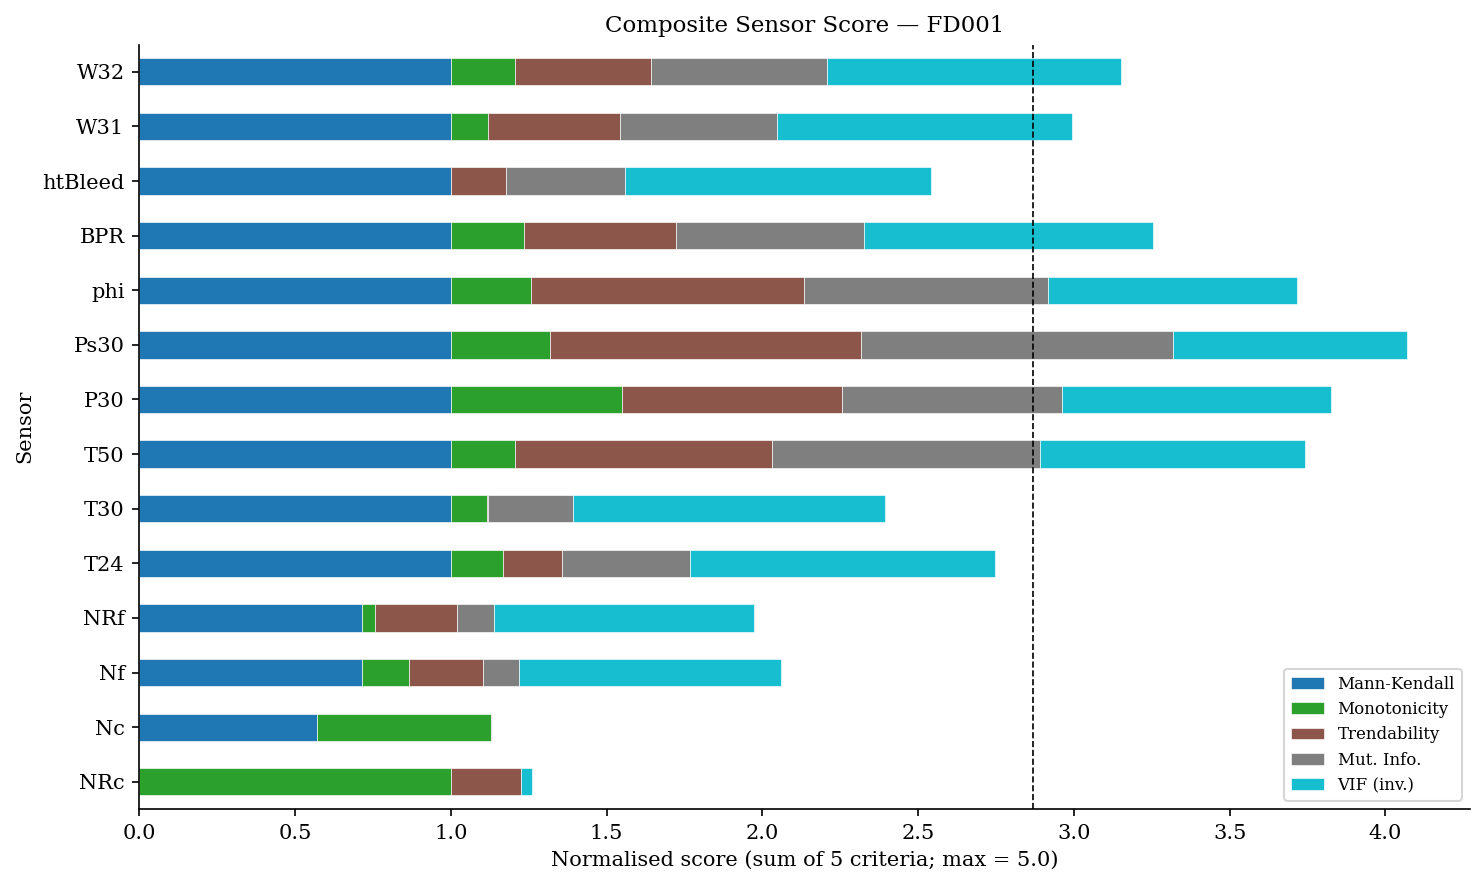

Saved → output/figures/EDA/composite_ranking_FD001.png


In [16]:
# Radar-style summary: stacked bar of normalised criteria per sensor (FD001)
criteria_cols = ['MK_norm', 'Mono_norm', 'Trend_norm', 'MI_norm', 'VIF_norm']
criteria_labels = ['Mann-Kendall', 'Monotonicity', 'Trendability', 'Mut. Info.', 'VIF (inv.)']

fd001_plot = (
    composite_df[composite_df['Dataset'] == 'FD001']
    .set_index('Sensor')[criteria_cols]
    .sort_values('MK_norm', ascending=True)
)
fd001_plot.columns = criteria_labels

fig, ax = plt.subplots(figsize=(10, 6))
fd001_plot.plot(kind='barh', stacked=True, ax=ax, colormap='tab10', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Normalised score (sum of 5 criteria; max = 5.0)')
ax.set_title('Composite Sensor Score — FD001', fontsize=11)
ax.legend(loc='lower right', fontsize=8)
ax.axvline(fd001_plot.sum(axis=1).median(), color='k', linestyle='--', linewidth=0.8, label='Median')
plt.tight_layout()
fig.savefig(FIG_DIR / 'composite_ranking_FD001.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/EDA/composite_ranking_FD001.png')

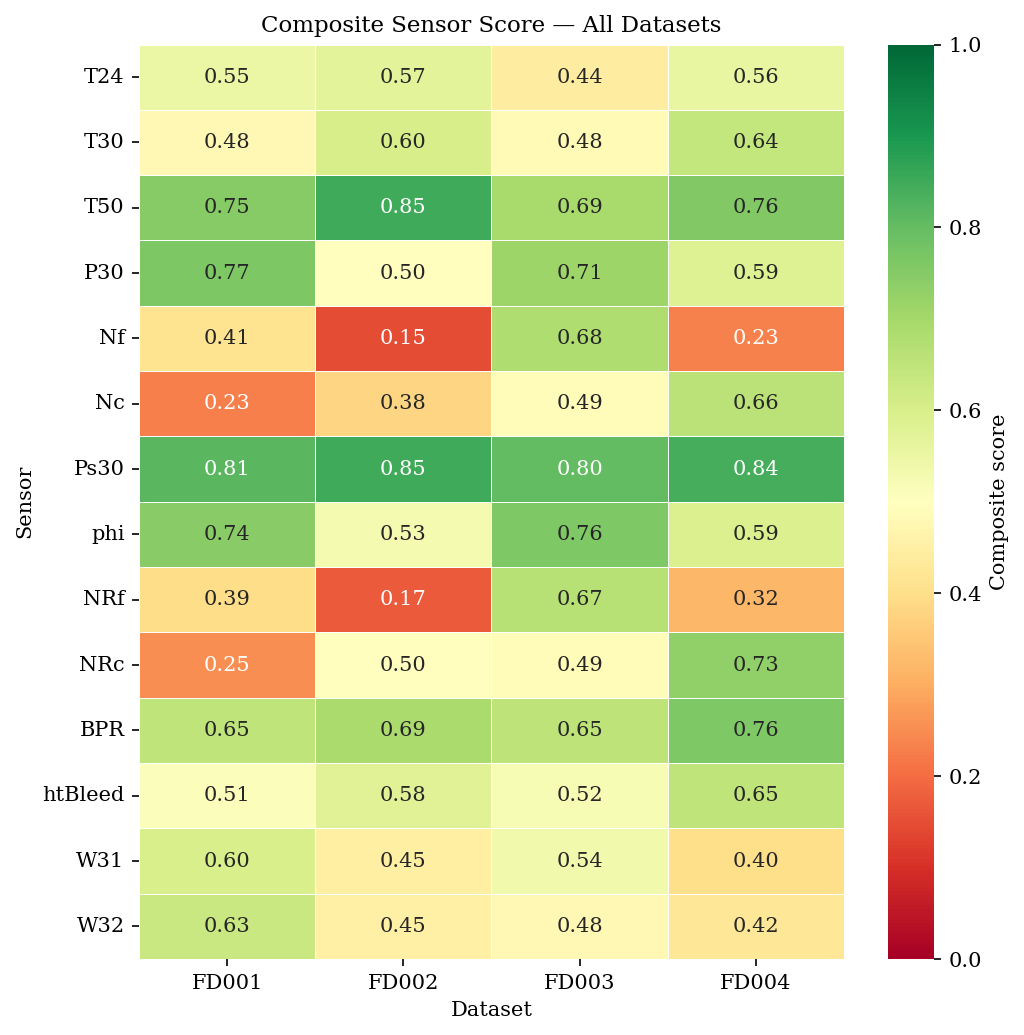

Saved → output/figures/EDA/composite_ranking_all_datasets.png


In [17]:
# Composite score heatmap across all datasets
comp_pivot = composite_df.pivot_table(index='Sensor', columns='Dataset', values='Composite').loc[INFORMATIVE]

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(
    comp_pivot, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Composite score'}
)
ax.set_title('Composite Sensor Score — All Datasets', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'composite_ranking_all_datasets.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/EDA/composite_ranking_all_datasets.png')

---
## 10. Final Sensor Selection

### Selection rules

1. **Composite score ≥ 0.40** (average across all 4 datasets) — removes sensors that are weak across the board  
2. **VIF ≤ 10** in FD001 — removes collinear duplicates  
3. Among sensors surviving (1)+(2), if two are highly correlated (|r| > 0.90), keep the one with higher composite score

The final list is the sensor subset used in all downstream experiments.

In [18]:
# Mean composite score across datasets
mean_comp = composite_df.groupby('Sensor')['Composite'].mean().sort_values(ascending=False)
print('Mean composite score across FD001-FD004:')
display(mean_comp.round(4).to_frame())

# Step 1: composite threshold
THRESHOLD_COMP = 0.40
step1 = mean_comp[mean_comp >= THRESHOLD_COMP].index.tolist()
print(f'\nAfter composite ≥ {THRESHOLD_COMP}: {step1}')

Mean composite score across FD001-FD004:


,Composite
Sensor,
Ps30,0.8276
T50,0.7614
BPR,0.6888
phi,0.6569
P30,0.6407
htBleed,0.5648
T30,0.5514
T24,0.5301
W32,0.4962



After composite ≥ 0.4: ['Ps30', 'T50', 'BPR', 'phi', 'P30', 'htBleed', 'T30', 'T24', 'W32', 'W31', 'NRc', 'Nc']


In [19]:
# Step 2: VIF filter (FD001)
fd001_vif_vals = vif_df[vif_df['Dataset'] == 'FD001'].set_index('Sensor')['VIF']
step2 = [s for s in step1 if fd001_vif_vals.get(s, 999) <= 10]
print(f'After VIF ≤ 10 (FD001): {step2}')

removed_vif = [s for s in step1 if s not in step2]
print(f'Removed by VIF: {removed_vif}')

After VIF ≤ 10 (FD001): ['Ps30', 'T50', 'BPR', 'phi', 'P30', 'htBleed', 'T30', 'T24', 'W32', 'W31']
Removed by VIF: ['NRc', 'Nc']


In [20]:
# Step 3: Remove within-group collinear duplicates (|r| > 0.90 in FD001)
corr_fd001 = data_norm['FD001'][[s + '_norm' for s in step2]].rename(
    columns=lambda c: c.replace('_norm', '')
).corr().abs()

to_drop = set()
for i, s1 in enumerate(step2):
    for s2 in step2[i+1:]:
        if s1 in to_drop or s2 in to_drop:
            continue
        r = corr_fd001.loc[s1, s2] if s1 in corr_fd001.index and s2 in corr_fd001.columns else 0
        if r > 0.90:
            # Keep the one with higher mean composite score
            drop = s1 if mean_comp[s1] < mean_comp[s2] else s2
            to_drop.add(drop)
            print(f'|r|({s1},{s2}) = {r:.2f} → dropping {drop}')

SELECTED_SENSORS = [s for s in step2 if s not in to_drop]
print(f'\nFinal selected sensors ({len(SELECTED_SENSORS)}): {SELECTED_SENSORS}')


Final selected sensors (10): ['Ps30', 'T50', 'BPR', 'phi', 'P30', 'htBleed', 'T30', 'T24', 'W32', 'W31']


In [21]:
# Save the final sensor list
pd.Series(SELECTED_SENSORS, name='sensor').to_csv(TABLE_DIR / 'selected_sensors.csv', index=False)
print('Saved → output/tables/EDA/selected_sensors.csv')

# Final ranking table
final_table = (
    composite_df[composite_df['Dataset'] == 'FD001']
    .set_index('Sensor')
    [['MK_sig_frac', 'Monotonicity', 'Trendability', 'MI', 'VIF', 'Composite']]
    .loc[SELECTED_SENSORS]
    .sort_values('Composite', ascending=False)
    .round(4)
)
final_table['Selected'] = True
display(final_table)
final_table.to_csv(TABLE_DIR / 'final_sensor_table.csv')
print('Saved → output/tables/EDA/final_sensor_table.csv')

Saved → output/tables/EDA/selected_sensors.csv


,MK_sig_frac,Monotonicity,Trendability,MI,VIF,Composite,Selected
Sensor,,,,,,,
Ps30,1.0,0.0390,0.8105,0.5016,5.93,0.8136,True
P30,1.0,0.0444,0.7614,0.4222,4.26,0.7652,True
T50,1.0,0.0364,0.7815,0.4632,4.47,0.7481,True
phi,1.0,0.0376,0.7896,0.4433,5.19,0.7435,True
BPR,1.0,0.0371,0.7247,0.3943,3.31,0.6509,True
W32,1.0,0.0364,0.7167,0.3834,3.10,0.6301,True
W31,1.0,0.0344,0.7141,0.3672,3.05,0.5985,True
T24,1.0,0.0355,0.6752,0.3423,2.59,0.5493,True
htBleed,1.0,0.0316,0.6731,0.3344,2.54,0.5081,True


Saved → output/tables/EDA/final_sensor_table.csv


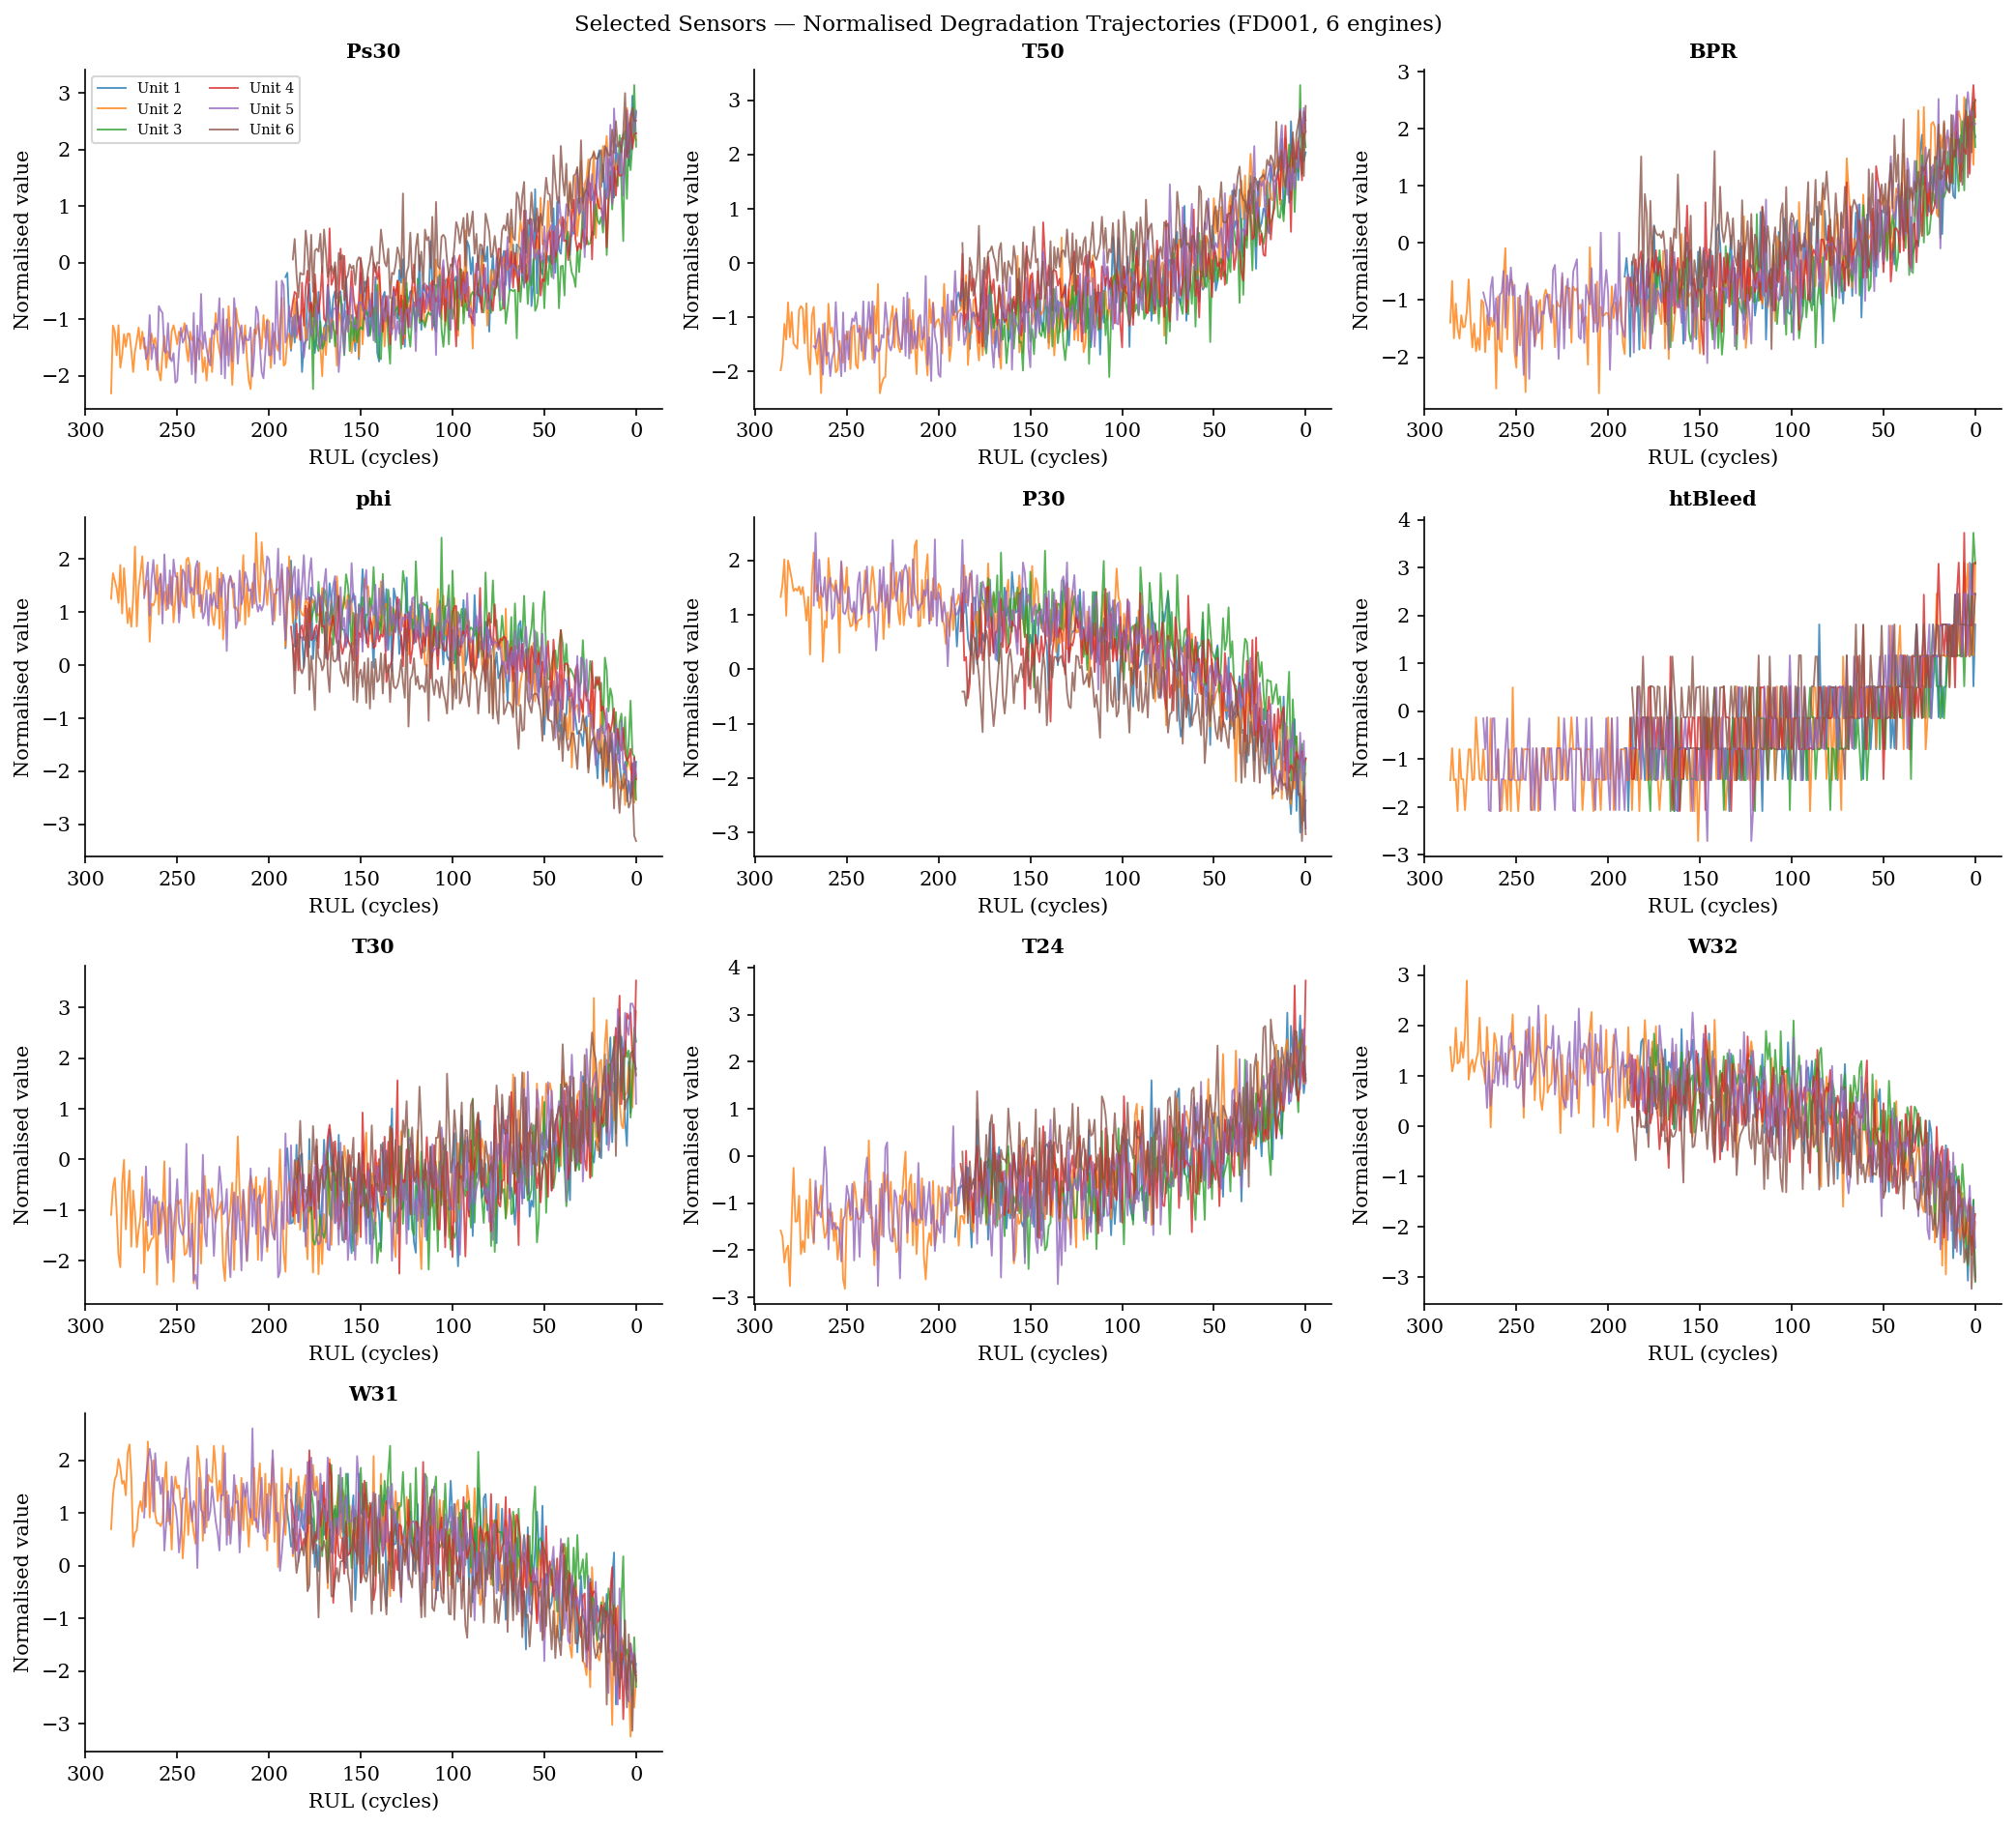

Saved → output/figures/EDA/selected_sensor_trajectories.png


In [22]:
# Degradation trajectories for selected sensors — FD001 training set
sample_units = list(data['FD001']['train']['unit_id'].unique()[:6])
df_train = data_norm['FD001']

n_sel = len(SELECTED_SENSORS)
ncols = 3
nrows = int(np.ceil(n_sel / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
axes = np.array(axes).flatten()
fig.suptitle('Selected Sensors — Normalised Degradation Trajectories (FD001, 6 engines)', fontsize=11)

for i, s in enumerate(SELECTED_SENSORS):
    ax = axes[i]
    for j, uid in enumerate(sample_units):
        grp = df_train[df_train['unit_id'] == uid].sort_values('cycle')
        ax.plot(grp['RUL'], grp[s + '_norm'],
                linewidth=0.9, alpha=0.8, color=PALETTE[j], label=f'Unit {uid}')
    ax.invert_xaxis()
    ax.set_title(s, fontsize=10, fontweight='bold')
    ax.set_xlabel('RUL (cycles)')
    ax.set_ylabel('Normalised value')
    if i == 0:
        ax.legend(fontsize=7, ncol=2)

for j in range(n_sel, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'selected_sensor_trajectories.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/EDA/selected_sensor_trajectories.png')

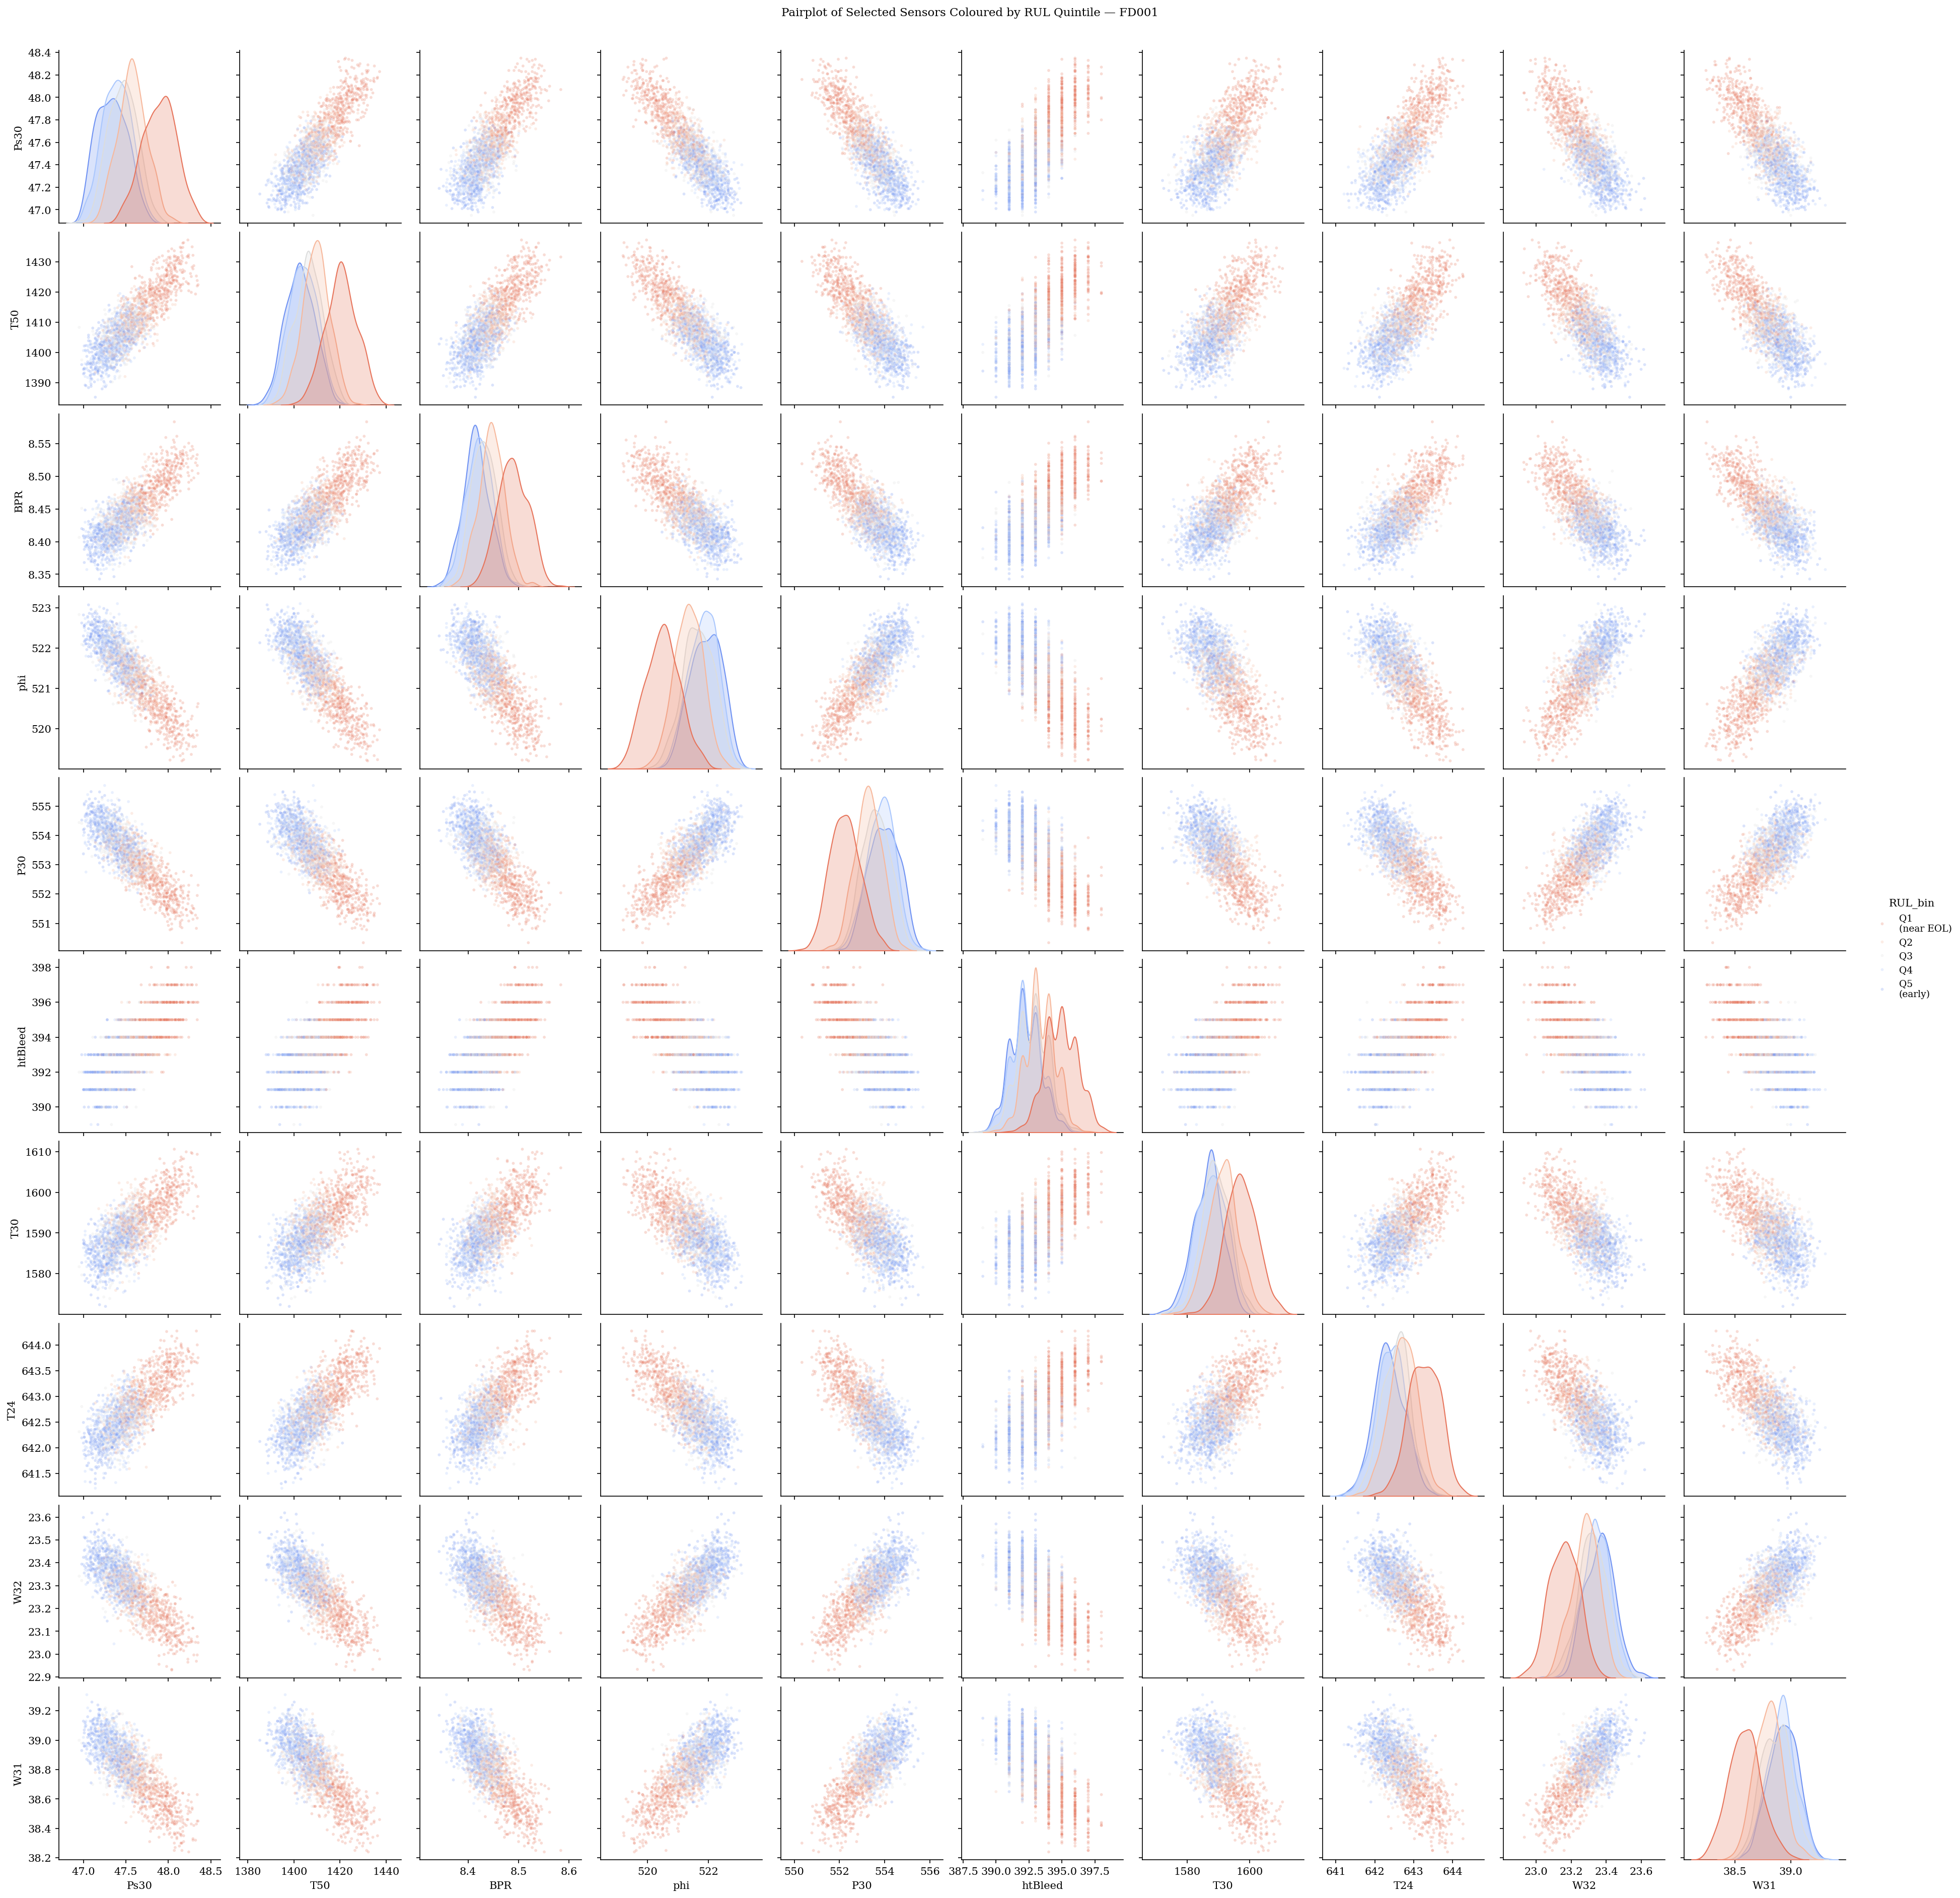

Saved → output/figures/EDA/selected_sensor_pairplot.png


In [23]:
# Pairplot of selected sensors coloured by RUL quintile (FD001 subsample)
df_sample = data_norm['FD001'][SELECTED_SENSORS + ['RUL']].sample(2000, random_state=42).copy()
df_sample.columns = [c.replace('_norm', '') for c in df_sample.columns]
df_sample['RUL_bin'] = pd.qcut(df_sample['RUL'], q=5, labels=['Q1\n(near EOL)', 'Q2', 'Q3', 'Q4', 'Q5\n(early)'])

g = sns.pairplot(
    df_sample, vars=SELECTED_SENSORS, hue='RUL_bin',
    plot_kws={'alpha': 0.25, 's': 8},
    diag_kind='kde',
    palette='coolwarm_r'
)
g.figure.suptitle('Pairplot of Selected Sensors Coloured by RUL Quintile — FD001', y=1.01, fontsize=11)
g.figure.savefig(FIG_DIR / 'selected_sensor_pairplot.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/EDA/selected_sensor_pairplot.png')

---
## 11. Summary & Conclusions

In [24]:
print('=' * 65)
print('  EDA SUMMARY')
print('=' * 65)

print(f"""
INPUT:  {len(INFORMATIVE)} informative sensors (after removing 7 constant sensors in IDA)
OUTPUT: {len(SELECTED_SENSORS)} selected sensors for downstream experiments

SELECTED SENSORS:
  {SELECTED_SENSORS}

SELECTION PIPELINE:
  1. Mann-Kendall test   — sig. fraction per sensor averaged over engines
  2. Monotonicity score  — directional consistency within each engine
  3. Trendability score  — degradation consistency across engines
  4. Mutual Information  — nonlinear relevance to RUL
  5. VIF (≤ 10)          — collinearity filter
  6. |r| > 0.90          — pairwise redundancy removal

OPERATING CONDITIONS:
  FD001/FD003: single regime — no normalisation needed
  FD002/FD004: 6 regimes — sensors z-scored within cluster before analysis

KEY COLLINEARITIES (identified by VIF / |r|):
  Nc ↔ NRc (highly correlated speed measures)
  Nf ↔ NRf (physical vs corrected fan speed)
  Ps30 ↔ phi (partial; kept if VIF allows)

NEXT STEP → models/ package
  Build data, sensor, degradation, inference, evaluation modules.
  Use SELECTED_SENSORS as the canonical sensor subset.
  Primary benchmark dataset: FD001 (single condition, single fault).
""")

  EDA SUMMARY

INPUT:  14 informative sensors (after removing 7 constant sensors in IDA)
OUTPUT: 10 selected sensors for downstream experiments

SELECTED SENSORS:
  ['Ps30', 'T50', 'BPR', 'phi', 'P30', 'htBleed', 'T30', 'T24', 'W32', 'W31']

SELECTION PIPELINE:
  1. Mann-Kendall test   — sig. fraction per sensor averaged over engines
  2. Monotonicity score  — directional consistency within each engine
  3. Trendability score  — degradation consistency across engines
  4. Mutual Information  — nonlinear relevance to RUL
  5. VIF (≤ 10)          — collinearity filter
  6. |r| > 0.90          — pairwise redundancy removal

OPERATING CONDITIONS:
  FD001/FD003: single regime — no normalisation needed
  FD002/FD004: 6 regimes — sensors z-scored within cluster before analysis

KEY COLLINEARITIES (identified by VIF / |r|):
  Nc ↔ NRc (highly correlated speed measures)
  Nf ↔ NRf (physical vs corrected fan speed)
  Ps30 ↔ phi (partial; kept if VIF allows)

NEXT STEP → models/ package
  Build d

---
*End of EDA notebook. All tables and figures saved to `/output/tables/EDA/` and `/output/figures/EDA/`.*